In [2]:
import random
import numpy as np

class KMeans:
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self,X):

        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            # assign clusters
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            # move centroids
            self.centroids = self.move_centroids(X,cluster_group)
            # check finish
            if (old_centroids == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self,X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self,X,cluster_group):
        new_centroids = []

        cluster_type = np.unique(cluster_group)

        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))

        return np.array(new_centroids)


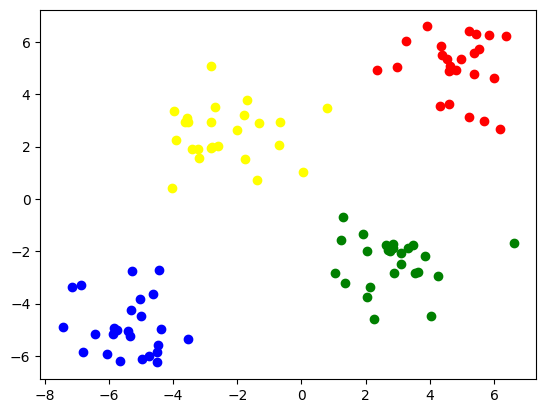

In [6]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

centroids = [(-5,-5),(5,5),(-2.5,2.5),(2.5,-2.5)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)

#plt.scatter(X[:,0],X[:,1])




km = KMeans(n_clusters=4,max_iter=500)
y_means = km.fit_predict(X)

plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')
plt.show()

#With WCSS

In [8]:
import random
import numpy as np

class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None
        self.wcss = 0  # Added WCSS

    def fit_predict(self, X):
        random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            self.centroids = self.move_centroids(X, cluster_group)

            # Calculate WCSS
            self.wcss = self.calculate_wcss(X, cluster_group)

            if (old_centroids == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self, X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid, row-centroid)))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centroids = []
        for type in range(self.n_clusters):  # Changed to range
            new_centroids.append(X[cluster_group == type].mean(axis=0))
        return np.array(new_centroids)

    def calculate_wcss(self, X, cluster_group):
        wcss = 0
        for i in range(self.n_clusters):
            cluster_points = X[cluster_group == i]
            if len(cluster_points) > 0:  # Handle empty clusters
                wcss += np.sum((cluster_points - self.centroids[i])**2)
        return wcss

In [9]:
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)
print("WCSS:", kmeans.wcss)

WCSS: 1128.3682856015648




## How K-Means Works (Step-by-Step)

1. **Initialization**:
   - Choose `k` random points from your data as initial "centroids" (cluster centers)
   - *Technically*: Select k observations uniformly at random from X as initial centroids

2. **Assignment Step**:
   - For each data point, calculate distance to all centroids
   - Assign each point to the nearest centroid (forming clusters)
   - *Technically*: Compute Euclidean distance (√Σ(xᵢ - cᵢ)²) between each point and all centroids

3. **Update Step**:
   - Recalculate centroids as the mean of all points in each cluster
   - *Technically*: For each cluster, compute μ = (1/n)Σxᵢ where n is cluster size

4. **Convergence Check**:
   - Repeat steps 2-3 until centroids stop moving or max iterations reached
   - *Technically*: Stop when ||μₜ - μₜ₋₁|| < ε (small threshold)

## Key Components in the Code

### 1. `fit_predict()` - Main Algorithm
- Randomly picks starting points (`random_index`)
- Loops through assignment and update steps
- Calculates WCSS (Within-Cluster Sum of Squares) each iteration
- Stops when centroids stabilize

### 2. `assign_clusters()` - Assignment Step
- For each point:
  - Calculates distances to all centroids
  - Finds closest centroid (minimum distance)
  - Assigns point to that cluster
- Returns array of cluster assignments

### 3. `move_centroids()` - Update Step
- For each cluster:
  - Finds all points in that cluster
  - Calculates their mean (new centroid position)
- Returns new centroids

### 4. `calculate_wcss()` - Quality Metric
- For each cluster:
  - Sums squared distances from points to their centroid
- WCSS = ΣΣ(x - μ)² (sum over all clusters and their points)
- Lower WCSS = tighter clusters (better)

## Technical Terms Explained Simply

- **Centroid**: The center point of a cluster (mean of all its points)
- **Euclidean Distance**: Straight-line distance between points (√(x² + y² + ...))
- **WCSS (Within-Cluster Sum of Squares)**:
  - Measures how "tight" clusters are
  - Sum of squared distances from each point to its centroid
  - Used to evaluate cluster quality

## Why It Works
The algorithm minimizes WCSS by iteratively:
1. Assigning points to nearest centroids (reducing individual distances)
2. Moving centroids to cluster means (reducing overall distances)

It's guaranteed to converge (though possibly to local optimum) because:
- Each step reduces WCSS
- WCSS is bounded below by 0

## Example Walkthrough
For 2D points and k=2:
1. Pick 2 random points as centroids
2. Assign all points to nearest centroid (2 clusters)
3. Recalculate centroids as cluster means
4. Repeat until centroids barely move
5. Final clusters minimize sum of squared distances

# **K-Means Clustering Interview Questions & Answers**

### **1. What is K-Means Clustering?**
**Answer:**  
K-Means is an **unsupervised machine learning algorithm** that groups similar data points into **K clusters**. It works by:
1. Randomly initializing **K centroids** (cluster centers).
2. Assigning each data point to the **nearest centroid**.
3. Recomputing centroids as the **mean of points** in each cluster.
4. Repeating until centroids **stop changing** (convergence).

**Key Properties:**  
- **Distance-based** (uses Euclidean distance by default).  
- **Iterative optimization** (minimizes Within-Cluster Sum of Squares, WCSS).  
- **Sensitive to initial centroids** (may converge to local optima).  

---

### **2. How is K (number of clusters) chosen in K-Means?**  
**Answer:**  
Common methods to choose K:  
1. **Elbow Method:**  
   - Plot **WCSS (Within-Cluster Sum of Squares)** vs. K.  
   - Pick the "elbow" point where WCSS stops decreasing sharply.  

2. **Silhouette Score:**  
   - Measures how similar a point is to its own cluster vs. other clusters.  
   - Higher score = better-defined clusters.  

3. **Domain Knowledge:**  
   - Sometimes, the problem dictates K (e.g., customer segmentation into 5 groups).  

---

### **3. What is WCSS, and why is it important?**  
**Answer:**  
- **WCSS (Within-Cluster Sum of Squares)** = Sum of squared distances of each point to its centroid.  
- **Formula:**  
  \[
  WCSS = \sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2
  \]
- **Why it matters:**  
  - K-Means **minimizes WCSS** to form tight clusters.  
  - Used in the **Elbow Method** to find optimal K.  

---

### **4. What are the limitations of K-Means?**  
**Answer:**  
1. **Sensitive to initial centroids** → May get stuck in **local optima** (solved by **K-Means++**).  
2. **Assumes spherical clusters** → Struggles with **non-convex** or **elongated clusters**.  
3. **Requires pre-defined K** → Need methods like the Elbow Method.  
4. **Outlier-sensitive** → A single outlier can shift centroids significantly.  

---

### **5. How does K-Means++ improve K-Means?**  
**Answer:**  
**K-Means++** improves initialization:  
1. **First centroid:** Randomly chosen.  
2. **Next centroids:** Chosen with probability proportional to squared distance from nearest centroid.  
- **Result:** Spreads initial centroids better → Faster convergence, better clusters.  

---

### **6. What is the difference between K-Means and Hierarchical Clustering?**  
| Feature        | K-Means                          | Hierarchical Clustering          |  
|---------------|--------------------------------|--------------------------------|  
| **Type**      | Partition-based               | Agglomerative/Divisive         |  
| **K Required**| Yes (predefined)              | No (dendrogram helps choose)   |  
| **Speed**     | Faster (O(n))                 | Slower (O(n² or O(n³))         |  
| **Output**    | Flat clusters                 | Tree-like structure (dendrogram)|  

---

### **7. How would you handle categorical data in K-Means?**  
**Answer:**  
K-Means **requires numerical data** (distance-based). Options:  
1. **One-Hot Encoding** (for nominal categories).  
2. **Target Encoding** (for ordinal categories).  
3. **Use K-Modes** (variant for categorical data).  

---

### **8. Explain the time complexity of K-Means.**  
**Answer:**  
- **Per iteration:** **O(n × K × d)**, where:  
  - **n** = number of points  
  - **K** = number of clusters  
  - **d** = dimensions  
- **Total complexity:** **O(I × n × K × d)** (I = iterations).  
- **Optimizations:**  
  - **Mini-Batch K-Means** (faster, works on subsets).  
  - **Elkan’s Algorithm** (uses triangle inequality to skip distance calculations).  

---

### **9. How would you scale K-Means for large datasets?**  
**Answer:**  
1. **Mini-Batch K-Means** → Uses random subsets of data.  
2. **PCA** → Reduce dimensions before clustering.  
3. **Approximate Nearest Neighbors (ANN)** → Faster distance calculations.  
4. **Distributed K-Means** (e.g., Spark MLlib).  

---

### **10. Can K-Means work with non-Euclidean distances?**  
**Answer:**  
- **Default:** Uses **Euclidean distance (L2 norm)**.  
- **Alternatives:**  
  - **K-Medoids (PAM)** → Works with **any distance metric** (e.g., Manhattan, cosine).  
  - **Kernel K-Means** → For non-linear clusters.  

---



---

### **Summary Table: Key K-Means Concepts**  
| Concept          | Explanation |  
|----------------|------------|  
| **Centroid**   | Mean of points in a cluster |  
| **WCSS**       | Sum of squared distances to centroids |  
| **Elbow Method** | Helps choose optimal K |  
| **K-Means++**  | Better centroid initialization |  
| **Limitations** | Needs K, spherical clusters, sensitive to outliers |  

